# GDL - Midterm n.2

In the second midterm assignment, you are required to implement the layers of a **Convolutional Neural Network (CNN)** using **only NumPy**. You will test your implementation using pre-trained parameters, which are provided in a `zip` file that you should extract in the `params/` folder.

You are **not** allowed to use JAX, PyTorch, TensorFlow, or any other ML framework.

**Summary.** Overall, you are required to implement the following functions:
1. **`conv2d`**. 2D convolution
3. **`max_pool`**. Max-pooling.
4. **`avg_pool`**. Average-pooling.
5. **`relu`**. ReLU activation function.
6. **`cnn_forward`**. Implements the CNN architecture described in the provided docstring.

**Evaluation.** You can test your implementation by loading the provided parameters and evaluating on four selected samples. We will check your implementation with further hidden tests.

**Do not alter Sections 1 and 3 of the notebook**, instead **work only in Section 2**.

⚠️ **Fill the following cell with your student ID (matricola) and submission ID** ⚠️

In [1]:
# your student "matricola" goes here
student_id = 000000
# the ID from the sheet circulated in classroom goes here
submission_id = 25

assert student_id is not None and submission_id is not None, "Fill the student_id and submission_id before submitting!"

### 1. Libraries and Data Loading

Run these cells to download MNIST and load parameters in the `params` dictionary. You should place all the provided `npy` files in the `params/` directory.

In [2]:
import os
import struct
import gzip
import hashlib
import urllib.request
import numpy as np

In [3]:
# Download MNIST

MNIST_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
MNIST_TEST_FILES = {
    "test_images": ("t10k-images-idx3-ubyte.gz", "8d422c7b0a1c1c79245a5bcf07fe86e33eeafee792b84584aec276f5a2dbc4e6"),
    "test_labels": ("t10k-labels-idx1-ubyte.gz", "f7ae60f92e00ec6debd23a6088c31dbd2371eca3ffa0defaefb259924204aec6"),
}
DATA_DIR = "mnist_data"

def _download_file(filename: str, expected_sha256: str) -> str:
    os.makedirs(DATA_DIR, exist_ok=True)
    filepath = os.path.join(DATA_DIR, filename)
    if os.path.exists(filepath):
        sha = hashlib.sha256(open(filepath, "rb").read()).hexdigest()
        if sha == expected_sha256:
            return filepath
        print(f"Hash mismatch for {filename}, re-downloading …")

    url = MNIST_URL + filename
    print(f"Downloading {url} …")
    urllib.request.urlretrieve(url, filepath)

    sha = hashlib.sha256(open(filepath, "rb").read()).hexdigest()
    if sha != expected_sha256:
        raise RuntimeError(
            f"SHA-256 mismatch for {filename}: expected {expected_sha256}, got {sha}"
        )
    return filepath

def _parse_images(filepath: str) -> np.ndarray:
    """Parse IDX image file -> (N, 1, 28, 28) float32 in [0, 1]."""
    with gzip.open(filepath, "rb") as f:
        _, num, rows, cols = struct.unpack(">IIII", f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(num, 1, rows, cols).astype(np.float32) / 255.0

def _parse_labels(filepath: str) -> np.ndarray:
    """Parse IDX label file -> (N,) int32."""
    with gzip.open(filepath, "rb") as f:
        _, num = struct.unpack(">II", f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.astype(np.int32)

def load_mnist_test():
    """Return (test_images, test_labels)."""
    paths = {k: _download_file(*v) for k, v in MNIST_TEST_FILES.items()}
    return _parse_images(paths["test_images"]), _parse_labels(paths["test_labels"])

test_images, test_labels = load_mnist_test()
print(f"\nTest set: {test_images.shape[0]} images, shape={test_images.shape}")


Test set: 10000 images, shape=(10000, 1, 28, 28)


In [4]:
# Load parameters

PARAM_NAMES = [
    "conv1_weight",
    "conv1_bias",
    "conv2_weight",
    "conv2_bias",
    "fc1_weight",
    "fc1_bias",
    "fc2_weight",
    "fc2_bias",
]
PARAMS_DIR = "params"


def load_params(params_dir: str) -> dict:
    """Load all .npy parameter files from params_dir into a dict."""
    params = {}
    print("Parameter\tShape")
    for name in PARAM_NAMES:
        filepath = os.path.join(params_dir, f"{name}.npy")
        if not os.path.exists(filepath):
            raise FileNotFoundError(
                f"Parameter file not found: {filepath}\n"
                "Make sure the params/ folder is in the working directory."
            )
        params[name] = np.load(filepath).astype(np.float32)
        print(f"{name}\t{params[name].shape}")
    return params

params = load_params(PARAMS_DIR)

Parameter	Shape
conv1_weight	(32, 1, 3, 3)
conv1_bias	(32,)
conv2_weight	(64, 32, 3, 3)
conv2_bias	(64,)
fc1_weight	(128, 1024)
fc1_bias	(128,)
fc2_weight	(10, 128)
fc2_bias	(10,)


### 2. CNN Implementation

Implement the five functions below using numpy only **WITHOUT USING `np.convolve`**. The implementation should highlight your understanding of the inner workings of a Convolutional Network, try to be expressive and avoid shortcuts!

The functions `conv2d`, `max_pool` and `avg_pool` must input and output batches in the `NCHW` format, where:
1. `N` is the number of samples,
2. `C` is the number of channels,
3. `H` is the height, and
4. `W` is the width.

In [5]:
def conv2d(
        x: np.ndarray, #input I: batch di immagini (N, C_in, H, W)
        w: np.ndarray, #Kernel (pesi): "filtri" da far scorrere su img -> (C_out = quantità filtri diversi, C_in = quantità canali di x, kH = altezza kernel, kW = larghezza kernel)
        b: np.ndarray, #Bias (costante): (C_out,)
        stride: int, 
        padding: int
        ) -> np.ndarray:
    
    """
    Bidimensional convolution from C_in input channels to C_out output channels.
    The convolution has kernel size (kH x kW) and arbitrary stride and padding.

    Shapes:
      - W: (C_out, C_in, kH, kW)
      - b: (C_out,)
    """

    """Theory (general) :
    Conv = smoothing operator between 2 signals (one fixed, the other slides -> computing a weighted-average signal)    
    -> discrete conv between image I and kernel K (kH x kW) on finite support [-M , +M]

    (I*K)(i,j) = sum(m)sum(n) I(i-m, j-n)K(m,n)
    """

    #Ottenimento parametri:
    N, C_in, H, W = x.shape
    C_out, C_in_by_w, kH, kW = w.shape

    assert(C_in == C_in_by_w), "C in by x and C in by w should be equal"

    #Padding H and W in x 
    x_padded = np.pad(x, ((0,0), (0,0), (padding,padding), (padding, padding)), mode='constant')

    #Calcolo dim output -> K è la size del kernel, P il padding e S lo stride:
    #W' = (W-K+2P)/S + 1
    #H' = (H-K+2P)/S + 1
    H_out = (H - kH + 2 * padding) // stride + 1
    W_out = (W - kW + 2 * padding) // stride + 1

    #Pre-allocazione del tensore per i risultati (N immagini, C_out canali/filtri, Altezza, Larghezza)
    out = np.zeros((N, C_out, H_out, W_out), dtype=np.float32)

    #Applicazione della convoluzione:
    for i in range(H_out) :
      for j in range(W_out):
        #get coordinates (i,j) in the padded image 
        h_start = i*stride
        h_end = h_start + kH
        
        col_start = j*stride
        col_end = col_start + kW

        #Patch of the image considering all N images, all C_in channels and spatial window -> x_slice : (N, C_in, kH, kW):
        x_slice = x_padded[:, :, h_start:h_end, col_start:col_end]

        #compute (I * K) where x_slice = I and w = K
        #use of np.tensordot to mul and sum on m,n and on C_in channels 
        #mul on 2 axes:
        # - axe 1 (C_in), axe 2 (kH), axe 3 (kW) of x_slice
        # - axe 1 (C_in), axe 2 (kH), axe 3 (kW) of w
        # ris -> tensor in (N, C_out) form that represent the value of a single pixel (i,j) for all the batch 
        out[:, :, i, j] = np.tensordot(x_slice, w, axes=([1,2,3], [1,2,3])) + b

    return out

In [6]:
def compute_pooling_support(x: np.ndarray, pool_size: int = 2, stride: int = 2, op_type = "max"):
    assert op_type == "max" or op_type == "avg", f"Wrong op type in pool support = {op_type} | possibilities = max or avg"

    #dimensions by the input param:
    N, C, H, W = x.shape

    #compute output dimensions:
    H_out = (H-pool_size) // stride + 1
    W_out = (W-pool_size) // stride + 1

    #pre allocation of the output tensor:
    out = np.zeros((N, C, H_out, W_out), dtype=np.float32)

    #scroll the spatial window:
    for i in range(H_out):
        for j in range(W_out):
            #compute coordinates of the window on the original image:
            h_start = i*stride
            h_end = h_start + pool_size

            w_start = j*stride
            w_end = w_start + pool_size

            #get the patch of the image -> x_slice with shape (N,C, pool_size, pool_size):
            x_slice = x[:, :, h_start:h_end, w_start:w_end]

            if op_type == "max" : 
                #get max value in the spatial window for each image and for each channel:
                out[:, :, i, j] = np.max(x_slice, axis=(2,3)) #axis=(2,3) cause x_slice has 4 dims -> 0 is N, axe 1 is C, axe 2 is h and axe 3 is width of the spatial window ≠ np.max(x_slice) => global max in all the batch and all the channels 
    
            else : # => op_type == "avg" 
                #get avg value in the spatial window for each image and for each channel:
                out[:, :, i, j] = np.mean(x_slice, axis=(2,3)) 
    
            
    
    return out    

In [7]:
def max_pool(x: np.ndarray, pool_size: int = 2, stride: int = 2) -> np.ndarray:
    """
    Max-pooling with arbitrary pool size and stride.
    """

    """Theory: 
    •Aggregates information by the feature extracted
    •Aggregation fn => loosing information (resolution) -> throw away pixels 
        -> maintain only interesting info + traslation and toration invariant
        -> shrink image dim + put in relation infos of far away pixels in the inizial image (=> abstaction)
    •Operates in indipentent way for each channel 
    
    Max pooling:
    -> maintain only the dominant (max) feature in every local region
    """
    
    return compute_pooling_support(x, pool_size, stride, "max")

In [8]:
def avg_pool(x: np.ndarray, pool_size: int = 2, stride: int = 2) -> np.ndarray:
    """
    Average-pooling with arbitrary pool size and stride.
    """
    return compute_pooling_support(x, pool_size, stride, "avg")

In [9]:
def relu(x: np.ndarray) -> np.ndarray:
    """
    Rectified Linear Unit activation.
    """
    
    """Theory:
    Non linear activation fn: 
    f(x) = max(0,x)    
    """
    return np.maximum(0, x) #compare element by element the 2 arrays -> return a new array with max values in each position


In [10]:
def cnn_forward(params: dict, x: np.ndarray) -> np.ndarray:
    """
    Forward pass of the CNN using pure NumPy.
    The architecture is:
        Conv1 (1->32, 3x3 kernel, stride=2, padding=1) -> ReLU -> AvgPool(2x2, stride=2)
        Conv2 (32->64, 3x3 kernel, stride=1, padding=2) -> ReLU -> MaxPool(2x2, stride=2)
        Flatten
        FC1 (1024->128) -> ReLU
        FC2 (128->10)
    """
    
    """Theory:
    • all the conv neurons that shares the weights must receive the same updateds during the training
        => delta_w = sum of gradients by all the connections that share that weight
    • (back)prop of gradient by layer N to layer N-1 require deconvolution (+ zero padding)
        
    """

    #Block 1:
    # Conv1 (1->32, 3x3 kernel, stride=2, padding=1) -> ReLU -> AvgPool(2x2, stride=2)
    out = conv2d(x, params['conv1_weight'], params['conv1_bias'], stride=2, padding=1)
    out = relu(out)
    out = avg_pool(out, pool_size=2, stride=2)

    #Block 2
    # Conv2 (32->64, 3x3 kernel, stride=1, padding=2) -> ReLU -> MaxPool(2x2, stride=2)
    out = conv2d(out, params['conv2_weight'], params['conv2_bias'], stride=1, padding=2)
    out = relu(out)
    out = max_pool(out, pool_size=2, stride=2)

    #Flatten:
    N = out.shape[0]
    out = out.reshape(N, -1) # => out (N, 1024)

    #Block 3 (fully connected)
    # FC1 (1024->128) -> ReLU
    out = np.dot(out, params['fc1_weight'].T) + params['fc1_bias']
    out = relu(out)

    #Block 4 (fully connected)
    # FC2: 128 -> 10
    out = np.dot(out, params['fc2_weight'].T) + params['fc2_bias']

    return out

### 3. Evaluation

This section evaluates your implementation on the MNIST test set using the pre-trained parameters. On the following images, a correct implementation correctly classifies the first two images and misclassifies the second two.

**Do not alter this section.**

In [11]:
indices = np.array([0, 1, 78, 320])
sample_images = test_images[indices]
sample_labels = test_labels[indices]

# Perform forward pass
logits = cnn_forward(params, sample_images)
predictions = np.argmax(logits, axis=-1)

for i in range(4):
    print(f"Index {i} | GT={sample_labels[i]} | cnn(x)={predictions[i]}")

Index 0 | GT=7 | cnn(x)=7
Index 1 | GT=2 | cnn(x)=2
Index 2 | GT=9 | cnn(x)=8
Index 3 | GT=9 | cnn(x)=8


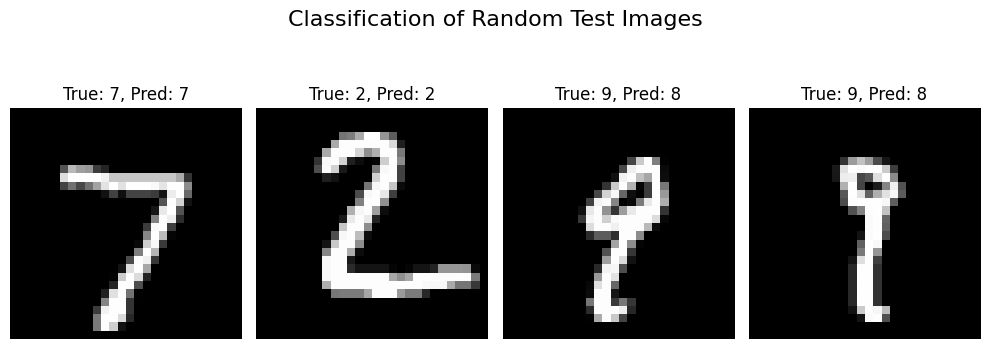

In [12]:
import matplotlib.pyplot as plt

# Display the images and their classifications
plt.figure(figsize=(10, 4))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(sample_images[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {sample_labels[i]}, Pred: {predictions[i]}")
    plt.axis('off')
plt.suptitle('Classification of Random Test Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()